# Feature Selection

Identify the top 4 features from Round 1 results.
The paper identifies: num_O, TPSA, HBA, HOMO.
We verify this through RF importance and LR coefficients.

In [1]:
import sys
sys.path.insert(0, '..')
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open('../data/results_round1.pkl', 'rb') as f:
    r1 = pickle.load(f)

results_r1 = r1['results']
feature_names = r1['feature_names']
print("Round 1 features:", feature_names)

Round 1 features: ['num_C', 'num_F', 'num_O', 'num_P', 'num_S', 'num_B', 'HOMO', 'LUMO', 'min_ESP', 'max_ESP', 'R', 'Lb', 'Lc', 'MW', 'TPSA', 'C', 'HBA']


In [2]:
# Feature importance from all tree-based models
from src.models import get_feature_importance

print("Feature Importance Comparison:")
print("=" * 70)
all_importance = {}
for name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    model = results_r1[name]['model']
    imp = get_feature_importance(model, feature_names)
    all_importance[name] = imp

# Average importance across tree models
avg_importance = {}
for feat in feature_names:
    avg_importance[feat] = np.mean([all_importance[m][feat] for m in all_importance])

sorted_feats = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)
print(f"{'Feature':<12} {'RF':>8} {'GB':>8} {'XGB':>8} {'Avg':>8}")
print("-" * 50)
for feat, avg in sorted_feats:
    rf_v = all_importance['Random Forest'][feat]
    gb_v = all_importance['Gradient Boosting'][feat]
    xgb_v = all_importance['XGBoost'][feat]
    print(f"{feat:<12} {rf_v:>8.4f} {gb_v:>8.4f} {xgb_v:>8.4f} {avg:>8.4f}")

Feature Importance Comparison:
Feature            RF       GB      XGB      Avg
--------------------------------------------------
TPSA           0.1193   0.4370   0.2362   0.2642
num_O          0.1243   0.0688   0.1443   0.1125
C              0.0812   0.0592   0.0636   0.0680
Lb             0.0728   0.0655   0.0605   0.0663
HOMO           0.0934   0.0541   0.0499   0.0658
MW             0.0755   0.0483   0.0671   0.0637
max_ESP        0.0827   0.0591   0.0447   0.0621
min_ESP        0.0541   0.0578   0.0702   0.0607
LUMO           0.0626   0.0524   0.0488   0.0546
Lc             0.0578   0.0478   0.0516   0.0524
R              0.0636   0.0101   0.0295   0.0344
HBA            0.0623   0.0064   0.0320   0.0336
num_S          0.0110   0.0102   0.0669   0.0294
num_C          0.0263   0.0054   0.0346   0.0221
num_P          0.0060   0.0158   0.0000   0.0073
num_F          0.0040   0.0021   0.0000   0.0020
num_B          0.0031   0.0000   0.0000   0.0010


Saved: /home/yhm/desktop/code/anion-paper/figures/lr_coefficients_round1.png


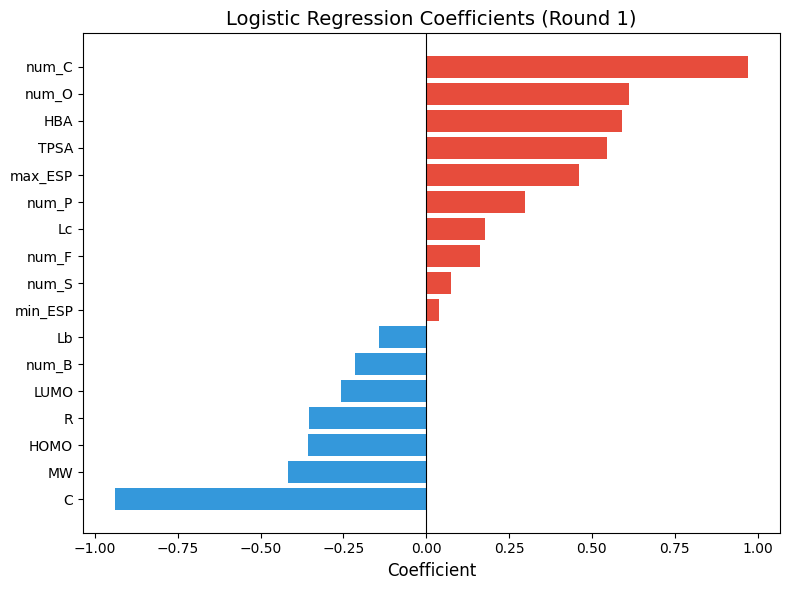


LR Coefficients (sorted):
       num_C: +0.9722 → Higher Eb
           C: -0.9409 → Lower Eb
       num_O: +0.6127 → Higher Eb
         HBA: +0.5915 → Higher Eb
        TPSA: +0.5448 → Higher Eb
     max_ESP: +0.4602 → Higher Eb
          MW: -0.4188 → Lower Eb
        HOMO: -0.3581 → Lower Eb
           R: -0.3544 → Lower Eb
       num_P: +0.2966 → Higher Eb
        LUMO: -0.2583 → Lower Eb
       num_B: -0.2149 → Lower Eb
          Lc: +0.1758 → Higher Eb
       num_F: +0.1633 → Higher Eb
          Lb: -0.1424 → Lower Eb
       num_S: +0.0751 → Higher Eb
     min_ESP: +0.0391 → Higher Eb


In [3]:
# Logistic Regression coefficients
from src.visualization import plot_lr_coefficients, save_fig

lr_model = results_r1['Logistic Regression']['model']
lr_coef = dict(zip(feature_names, lr_model.coef_[0]))
fig = plot_lr_coefficients(lr_coef, title="Logistic Regression Coefficients (Round 1)")
save_fig(fig, "lr_coefficients_round1.png")
plt.show()

print("\nLR Coefficients (sorted):")
for feat, coef in sorted(lr_coef.items(), key=lambda x: abs(x[1]), reverse=True):
    direction = "\u2192 Higher Eb" if coef > 0 else "\u2192 Lower Eb"
    print(f"  {feat:>10}: {coef:+.4f} {direction}")

In [4]:
# Top 4 features identification
from src.preprocessing import TOP4_FEATURES

print(f"Top 4 features identified by the paper: {TOP4_FEATURES}")
print("\nPhysical interpretation:")
print("  num_O: More oxygen \u2192 more coordination sites with Pb2+ (positive)")
print("  TPSA:  Larger polar surface area \u2192 more hydrogen bonding (positive)")
print("  HBA:   More H-bond acceptors \u2192 stronger interaction (positive)")
print("  HOMO:  Lower HOMO \u2192 higher electronegativity \u2192 stronger Eb (negative coefficient)")

Top 4 features identified by the paper: ['num_O', 'TPSA', 'HBA', 'HOMO']

Physical interpretation:
  num_O: More oxygen → more coordination sites with Pb2+ (positive)
  TPSA:  Larger polar surface area → more hydrogen bonding (positive)
  HBA:   More H-bond acceptors → stronger interaction (positive)
  HOMO:  Lower HOMO → higher electronegativity → stronger Eb (negative coefficient)


In [5]:
# Prepare round 2 data with top 4 features
from src.data_loader import load_dataset
from src.preprocessing import preprocess_data, split_data, standardize

df = load_dataset()
X4, y4 = preprocess_data(df, select_features=TOP4_FEATURES)
X4_train, X4_test, y4_train, y4_test = split_data(X4, y4, test_size=0.15)
X4_train_s, X4_test_s, scaler4 = standardize(X4_train, X4_test)

import pickle
prep_data_r2 = {
    'X_train': X4_train, 'X_test': X4_test,
    'X_train_s': X4_train_s, 'X_test_s': X4_test_s,
    'y_train': y4_train, 'y_test': y4_test,
    'scaler': scaler4,
    'feature_names': TOP4_FEATURES,
}
with open('../data/preprocessed_round2.pkl', 'wb') as f:
    pickle.dump(prep_data_r2, f)
print(f"Round 2 data prepared: {X4_train.shape[1]} features = {TOP4_FEATURES}")

Round 2 data prepared: 4 features = ['num_O', 'TPSA', 'HBA', 'HOMO']
